<a href="https://colab.research.google.com/github/Austinejacob/3MTT-GIT-ASSIGNMENT/blob/main/Nigeria_Housing_Demand_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏠 Nigeria Housing Demand — Complete Data Analysis
**Dataset:** 10,000 records | 37 States + FCT | 2015–2024  
**Target:** Housing Demand Score (1–10) & Demand Category  
---

## 1. 📦 Install & Import Libraries

In [2]:
# Install required libraries (uncomment if needed)
# !pip install pandas numpy matplotlib seaborn scikit-learn plotly openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (classification_report, confusion_matrix,
                             mean_squared_error, r2_score, mean_absolute_error)
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})
print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


## 2. 📂 Load Dataset

In [4]:
# ── Option A: Upload from your computer ──────────────────────────────────────
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv(list(uploaded.keys())[0])

# ── Option B: Load from Google Drive ─────────────────────────────────────────
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/nigeria_housing_demand_10000.csv')

# ── Option C: Load from URL (GitHub / direct link) ───────────────────────────
# df = pd.read_csv('YOUR_CSV_URL_HERE')

# ── Demo: Simulate the dataset inline (run this if no file available) ────────
import io, requests
# Replace with your actual file URL or use upload option above
# df = pd.read_csv(io.StringIO(uploaded_data))

# ── Placeholder load (replace with your preferred option above) ──────────────
df = pd.read_csv('nigeria_housing_demand_10000.csv')
print(f"✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

✅ Dataset loaded: 10,000 rows × 33 columns


,Record_ID,State,Geo_Zone,LGA_Type,Year,Population_Density_per_sqkm,Urbanization_Rate_%,Household_Size,Age_of_Household_Head,Education_Level,...,Security_Level,Proximity_to_Market_km,Proximity_to_School_km,Proximity_to_Hospital_km,Crowding_Index,Years_in_Current_Location,Intends_to_Move,Housing_Satisfaction,Housing_Demand_Score,Demand_Category
0,NGA-00001,Borno,North-East,Urban,2015,4283,45,4,48,No Formal,...,Low,0,1,4,1.33,2,No,Neutral,5.7,Moderate
1,NGA-00002,Kaduna,North-West,Urban,2018,6423,60,3,35,No Formal,...,Medium,0,3,2,0.60,1,Yes,Satisfied,9.2,Very High
2,NGA-00003,Gombe,North-East,Rural,2017,267,45,2,38,No Formal,...,Medium,6,1,0,0.40,2,Yes,Dissatisfied,4.1,Low
3,NGA-00004,Benue,North-Central,Urban,2023,2088,45,4,45,Primary,...,Low,0,4,3,1.33,11,No,Very Dissatisfied,6.1,Moderate
4,NGA-00005,Bayelsa,South-South,Urban,2024,962,45,2,38,Tertiary,...,Medium,1,0,4,0.67,22,Yes,Neutral,7.3,High


## 3. 🔍 Exploratory Data Analysis (EDA)

### 3.1 Dataset Overview

In [6]:
print("=" * 60)
print("DATASET SHAPE:", df.shape)
print("=" * 60)
print("\nCOLUMN NAMES:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. {col}")

DATASET SHAPE: (10000, 33)

COLUMN NAMES:
   1. Record_ID
   2. State
   3. Geo_Zone
   4. LGA_Type
   5. Year
   6. Population_Density_per_sqkm
   7. Urbanization_Rate_%
   8. Household_Size
   9. Age_of_Household_Head
  10. Education_Level
  11. Employment_Status
  12. Monthly_HH_Income_NGN
  13. House_Type
  14. Ownership_Status
  15. Number_of_Rooms
  16. House_Age_Years
  17. Annual_Rent_NGN
  18. Land_Price_per_sqm_NGN
  19. Mortgage_Access
  20. Infrastructure_Level
  21. Water_Supply
  22. Power_Supply_Hours_per_day
  23. Road_Quality
  24. Security_Level
  25. Proximity_to_Market_km
  26. Proximity_to_School_km
  27. Proximity_to_Hospital_km
  28. Crowding_Index
  29. Years_in_Current_Location
  30. Intends_to_Move
  31. Housing_Satisfaction
  32. Housing_Demand_Score
  33. Demand_Category


In [7]:
print("\nDATA TYPES & NON-NULL COUNTS:")
df.info()


DATA TYPES & NON-NULL COUNTS:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Record_ID                    10000 non-null  object 
 1   State                        10000 non-null  object 
 2   Geo_Zone                     10000 non-null  object 
 3   LGA_Type                     10000 non-null  object 
 4   Year                         10000 non-null  int64  
 5   Population_Density_per_sqkm  10000 non-null  int64  
 6   Urbanization_Rate_%          10000 non-null  int64  
 7   Household_Size               10000 non-null  int64  
 8   Age_of_Household_Head        10000 non-null  int64  
 9   Education_Level              10000 non-null  object 
 10  Employment_Status            10000 non-null  object 
 11  Monthly_HH_Income_NGN        10000 non-null  int64  
 12  House_Type                   10000 non-null 

In [8]:
print("\nDESCRIPTIVE STATISTICS — Numeric Columns:")
df.describe().round(2)


DESCRIPTIVE STATISTICS — Numeric Columns:


,Year,Population_Density_per_sqkm,Urbanization_Rate_%,Household_Size,Age_of_Household_Head,Monthly_HH_Income_NGN,Number_of_Rooms,House_Age_Years,Annual_Rent_NGN,Land_Price_per_sqm_NGN,Power_Supply_Hours_per_day,Proximity_to_Market_km,Proximity_to_School_km,Proximity_to_Hospital_km,Crowding_Index,Years_in_Current_Location,Housing_Demand_Score
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,2019.51,2151.75,52.35,3.32,41.68,65397.47,3.76,14.31,210469.83,36281.29,5.70,2.51,1.57,4.56,1.04,6.60,6.22
std,2.88,3118.31,12.96,1.11,9.71,52106.81,1.29,13.94,316337.02,50448.77,3.44,2.97,1.99,4.89,0.67,6.75,2.15
min,2015.00,50.00,45.00,2.00,22.00,15000.00,1.00,1.00,0.00,562.00,0.00,0.00,0.00,0.00,0.25,1.00,1.40
25%,2017.00,207.00,45.00,2.00,35.00,33134.00,3.00,4.00,0.00,6898.25,3.00,0.00,0.00,1.00,0.60,1.00,4.40
50%,2019.00,1009.50,45.00,3.00,42.00,51732.00,4.00,10.00,99950.00,18268.00,6.00,2.00,1.00,3.00,1.00,4.00,6.20
75%,2022.00,2895.00,60.00,4.00,48.00,80169.75,5.00,20.00,305807.00,44723.25,8.00,4.00,2.00,7.00,1.25,9.00,7.80
max,2024.00,30000.00,92.00,9.00,75.00,800000.00,8.00,60.00,5000000.00,500000.00,18.00,20.00,15.00,30.00,7.00,40.00,10.00


In [9]:
print("\nDESCRIPTIVE STATISTICS — Categorical Columns:")
df.describe(include='object')


DESCRIPTIVE STATISTICS — Categorical Columns:


,Record_ID,State,Geo_Zone,LGA_Type,Education_Level,Employment_Status,House_Type,Ownership_Status,Mortgage_Access,Infrastructure_Level,Water_Supply,Road_Quality,Security_Level,Intends_to_Move,Housing_Satisfaction,Demand_Category
count,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000
unique,10000,37,6,2,4,5,6,4,2,4,4,3,3,2,5,4
top,NGA-09984,Kebbi,North-West,Urban,Secondary,Self-Employed,Flat/Apartment,Rented,No,Fair,Borehole,Fair,Medium,No,Satisfied,Moderate
freq,1,303,1922,5277,3029,3490,3502,5473,9076,3188,3724,3842,4527,6517,2549,2751


### 3.2 Missing Values Check

In [11]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print("✅ No missing values found! Dataset is complete.")
else:
    print(missing_df)

    fig, ax = plt.subplots(figsize=(10, 4))
    missing_df['Missing %'].plot(kind='bar', ax=ax, color='#E74C3C')
    ax.set_title('Missing Values by Column (%)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Missing %')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

✅ No missing values found! Dataset is complete.


### 3.3 Duplicate Records

In [ ]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
if dupes > 0:
    df = df.drop_duplicates()
    print(f"✅ Duplicates removed. New shape: {df.shape}")

## 4. 📊 Univariate Analysis

### 4.1 Target Variable Distribution

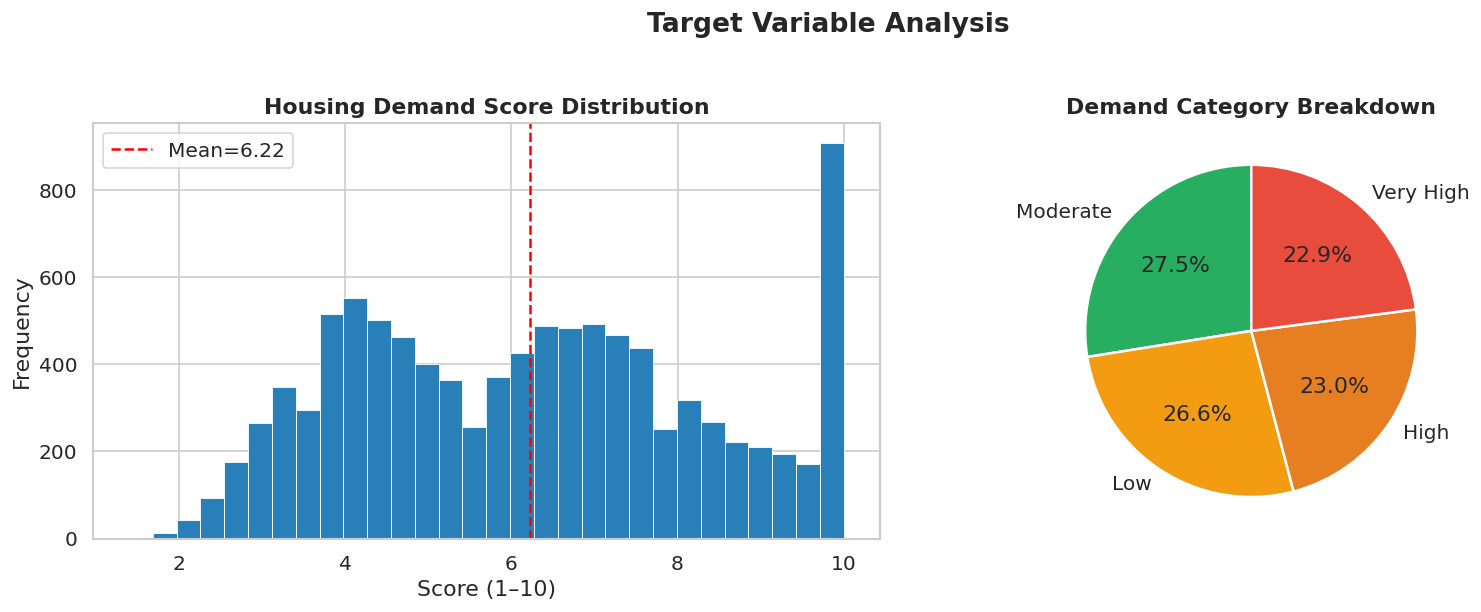

Demand_Category
Moderate     2751
Low          2659
High         2297
Very High    2293
Name: count, dtype: int64


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score histogram
axes[0].hist(df['Housing_Demand_Score'], bins=30, color='#2980B9', edgecolor='white', linewidth=0.5)
axes[0].set_title('Housing Demand Score Distribution', fontweight='bold')
axes[0].set_xlabel('Score (1–10)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['Housing_Demand_Score'].mean(), color='red', linestyle='--', label=f"Mean={df['Housing_Demand_Score'].mean():.2f}")
axes[0].legend()

# Category pie
cat_counts = df['Demand_Category'].value_counts()
colors_pie = ['#27AE60','#F39C12','#E67E22','#E74C3C']
axes[1].pie(cat_counts, labels=cat_counts.index, autopct='%1.1f%%',
            colors=colors_pie, startangle=90, wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Demand Category Breakdown', fontweight='bold')

plt.suptitle('Target Variable Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(cat_counts)

### 4.2 Numeric Feature Distributions

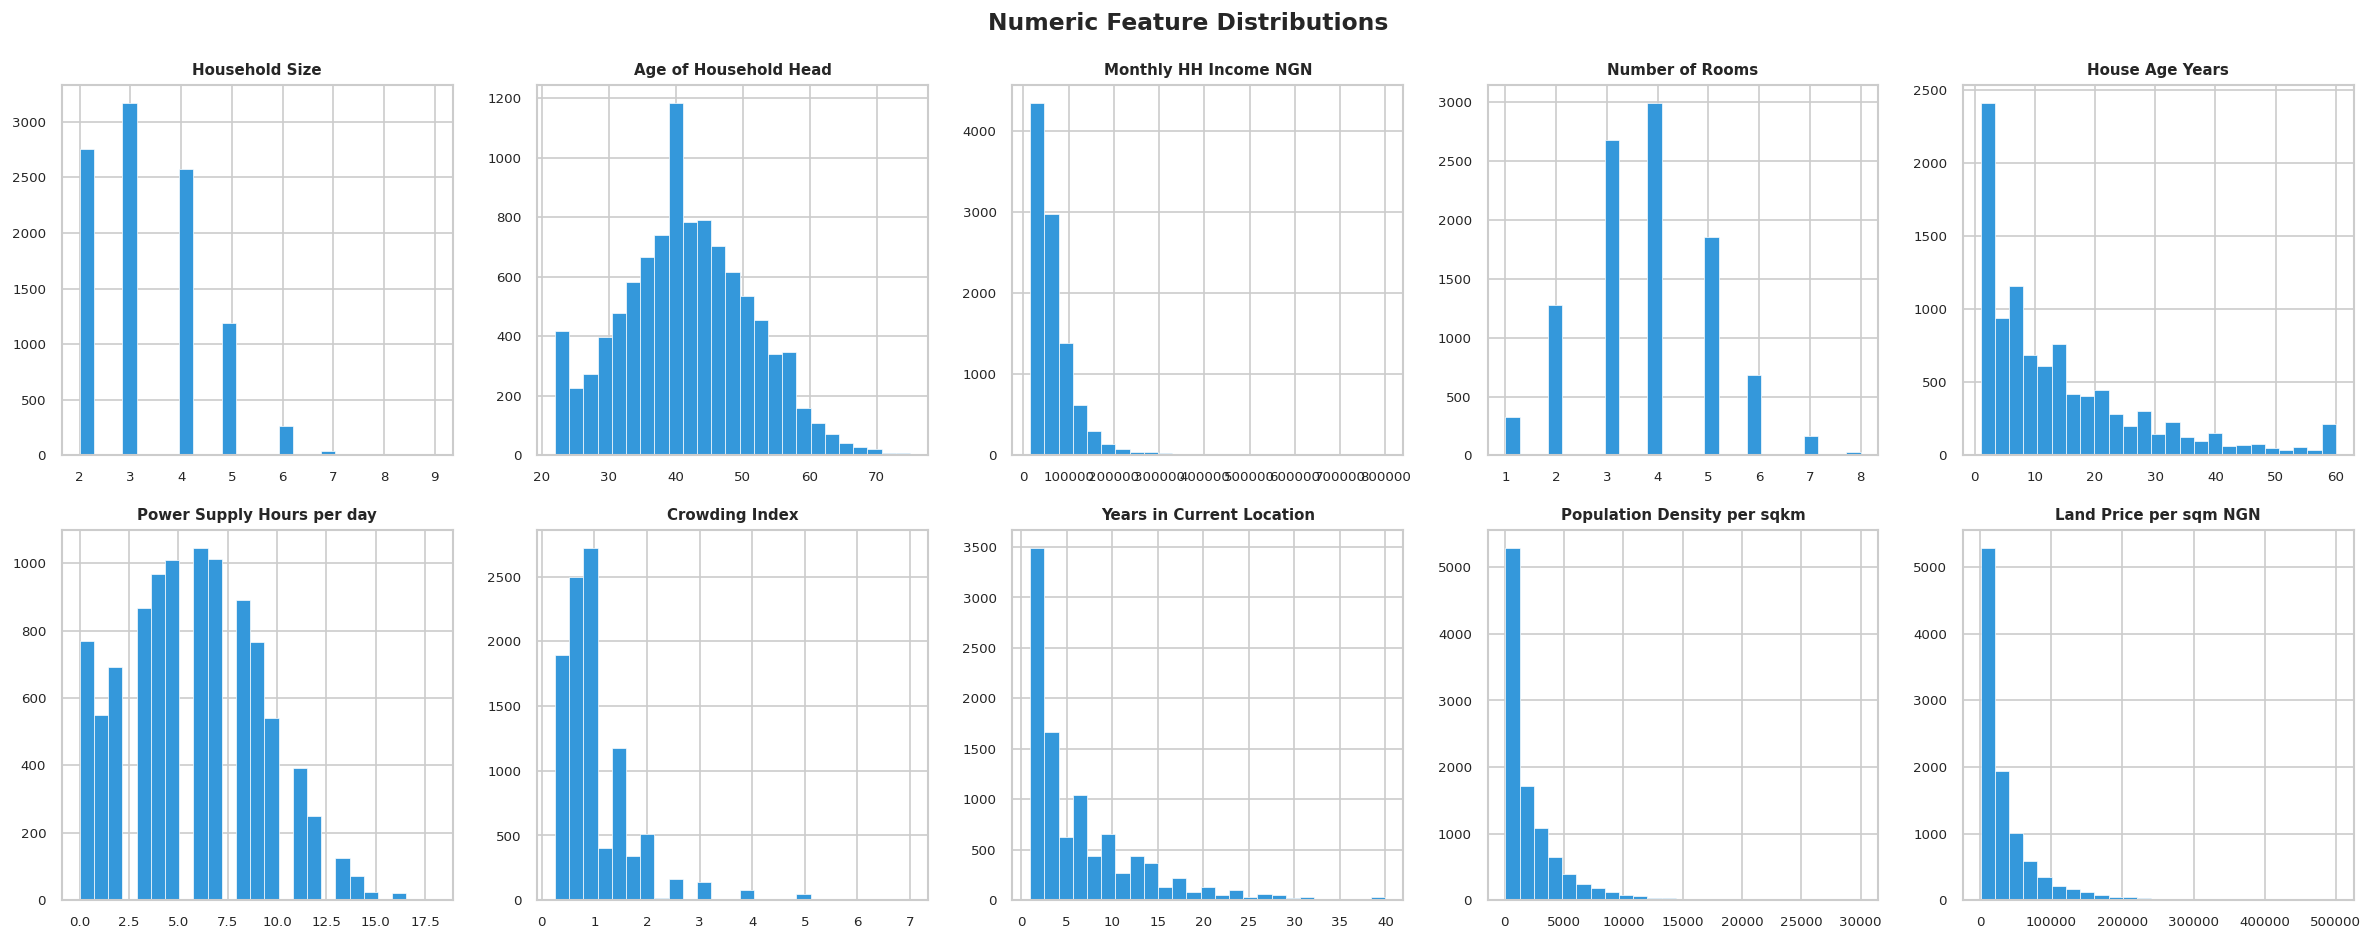

In [14]:
num_cols = ['Household_Size','Age_of_Household_Head','Monthly_HH_Income_NGN',
            'Number_of_Rooms','House_Age_Years','Power_Supply_Hours_per_day',
            'Crowding_Index','Years_in_Current_Location','Population_Density_per_sqkm',
            'Land_Price_per_sqm_NGN']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=25, color='#3498DB', edgecolor='white', linewidth=0.4)
    axes[i].set_title(col.replace('_', ' '), fontsize=9, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(labelsize=8)

plt.suptitle('Numeric Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.3 Categorical Feature Distributions

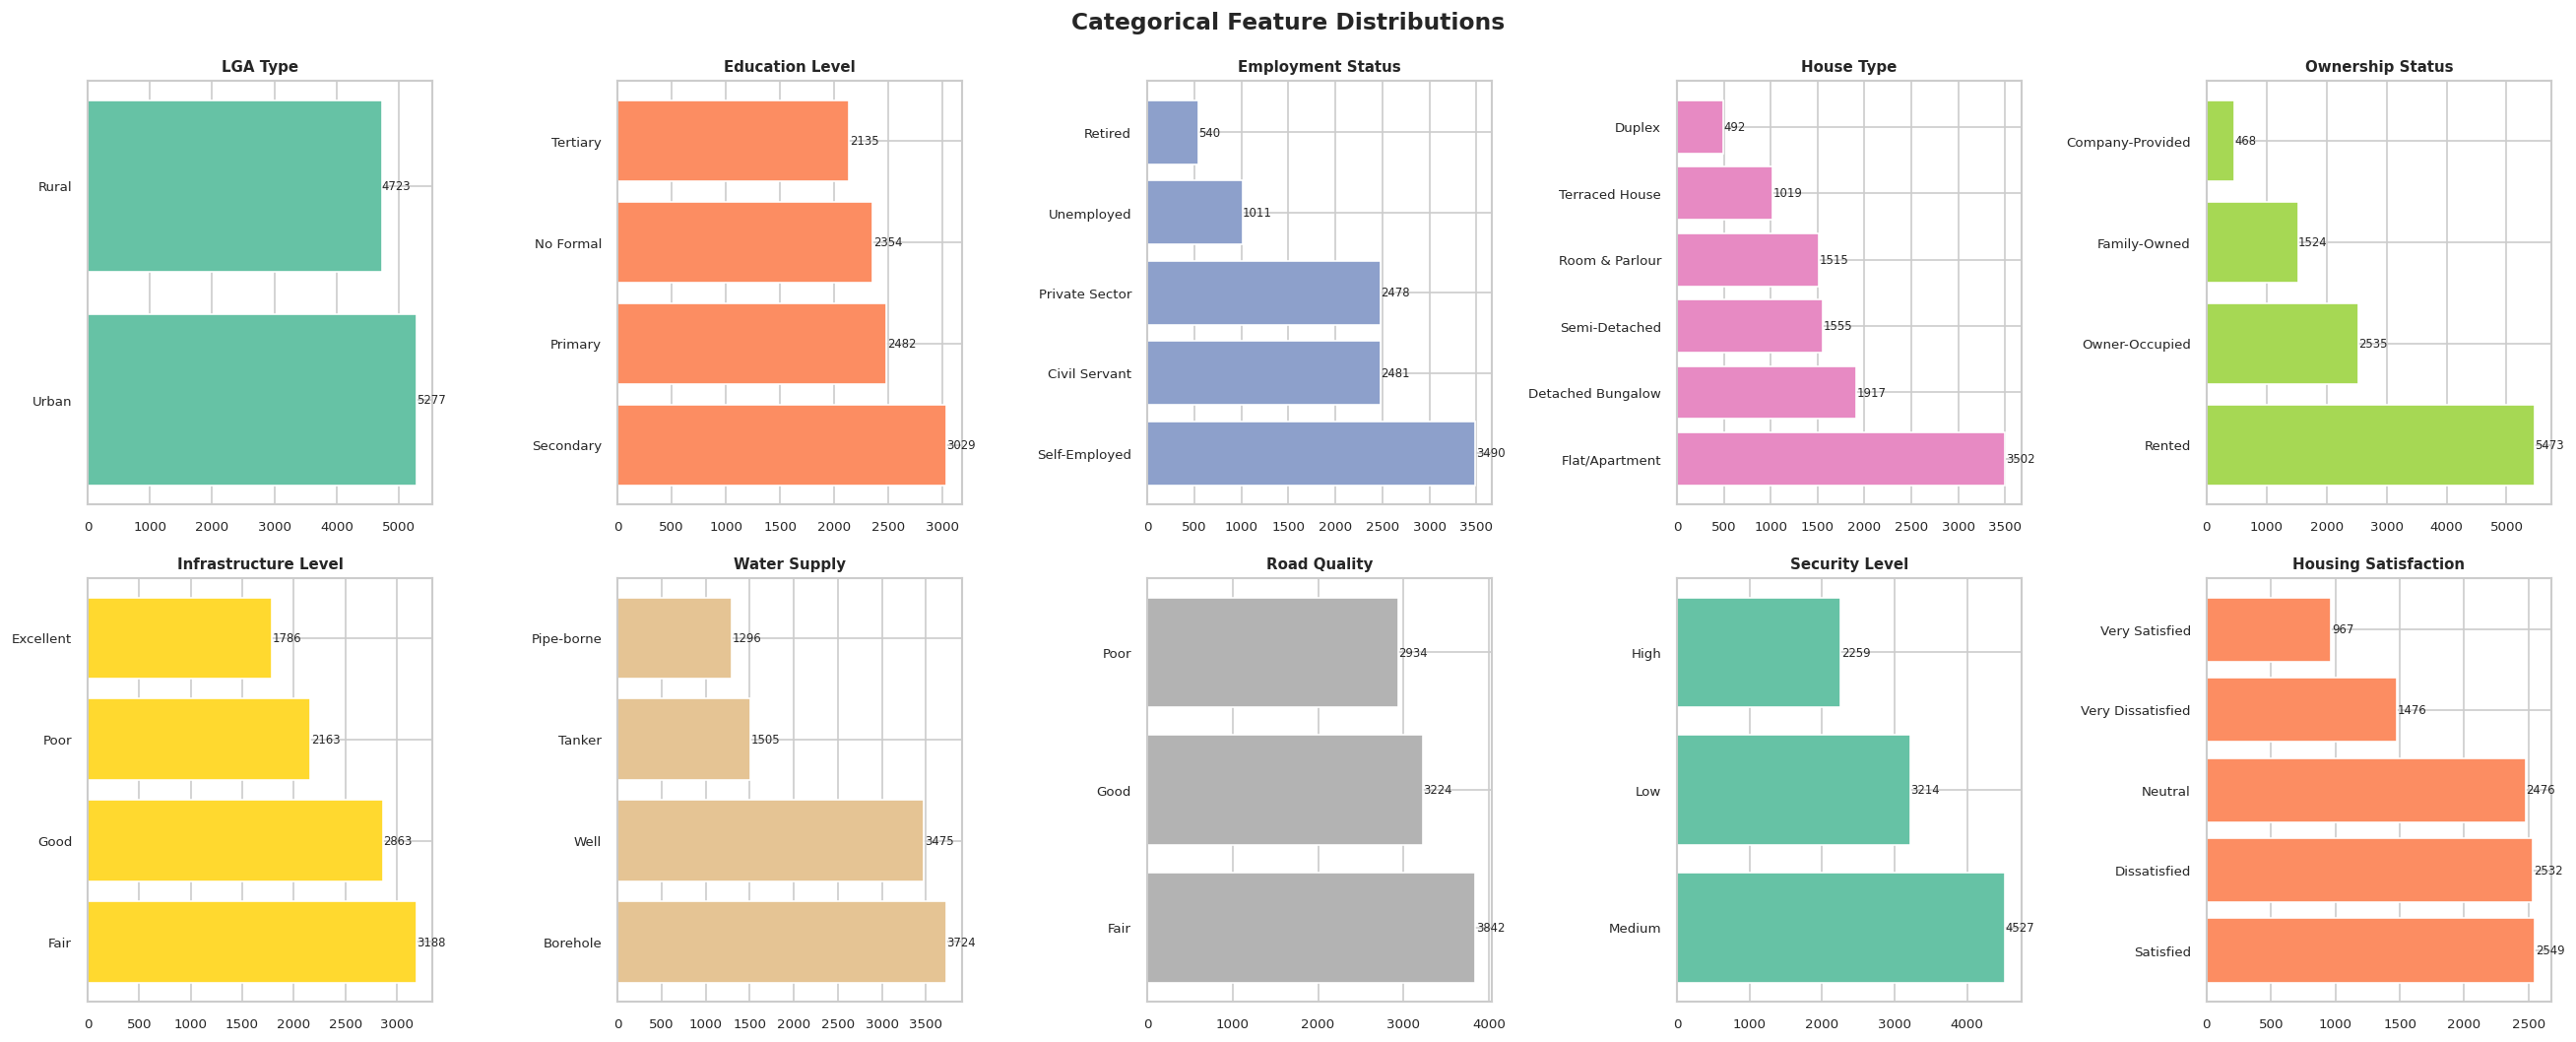

In [15]:
cat_cols = ['LGA_Type','Education_Level','Employment_Status','House_Type',
            'Ownership_Status','Infrastructure_Level','Water_Supply',
            'Road_Quality','Security_Level','Housing_Satisfaction']

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

palette = sns.color_palette('Set2', 10)

for i, col in enumerate(cat_cols):
    vc = df[col].value_counts()
    axes[i].barh(vc.index, vc.values, color=palette[i % len(palette)])
    axes[i].set_title(col.replace('_',' '), fontsize=9, fontweight='bold')
    axes[i].tick_params(labelsize=8)
    for j, v in enumerate(vc.values):
        axes[i].text(v + 5, j, str(v), va='center', fontsize=7)

plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. 🔗 Bivariate Analysis

### 5.1 Demand Score by State

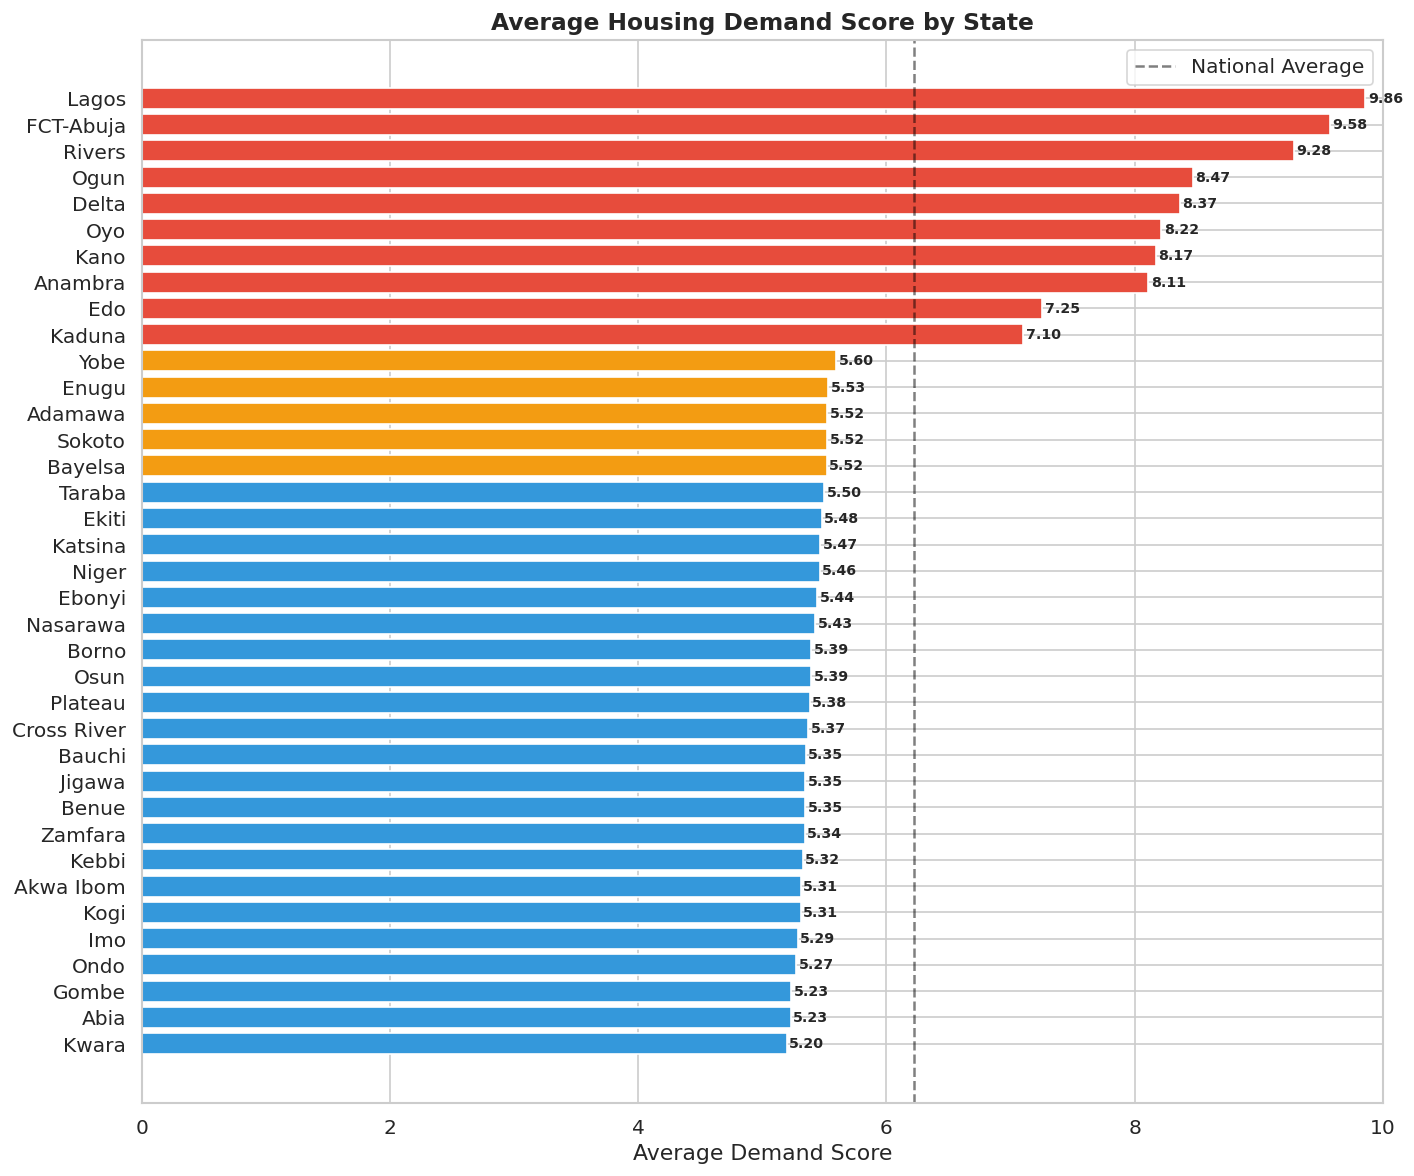

In [17]:
state_avg = df.groupby('State')['Housing_Demand_Score'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 10))
colors_bar = ['#E74C3C' if v >= 7 else '#F39C12' if v >= 5.5 else '#3498DB' for v in state_avg]
bars = ax.barh(state_avg.index, state_avg.values, color=colors_bar, edgecolor='white')

for bar, val in zip(bars, state_avg.values):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=8.5, fontweight='bold')

ax.set_title('Average Housing Demand Score by State', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Demand Score')
ax.set_xlim(0, 10)
ax.axvline(df['Housing_Demand_Score'].mean(), color='black', linestyle='--', alpha=0.5, label='National Average')
ax.legend()
plt.tight_layout()
plt.show()

### 5.2 Demand Score by Key Categorical Variables

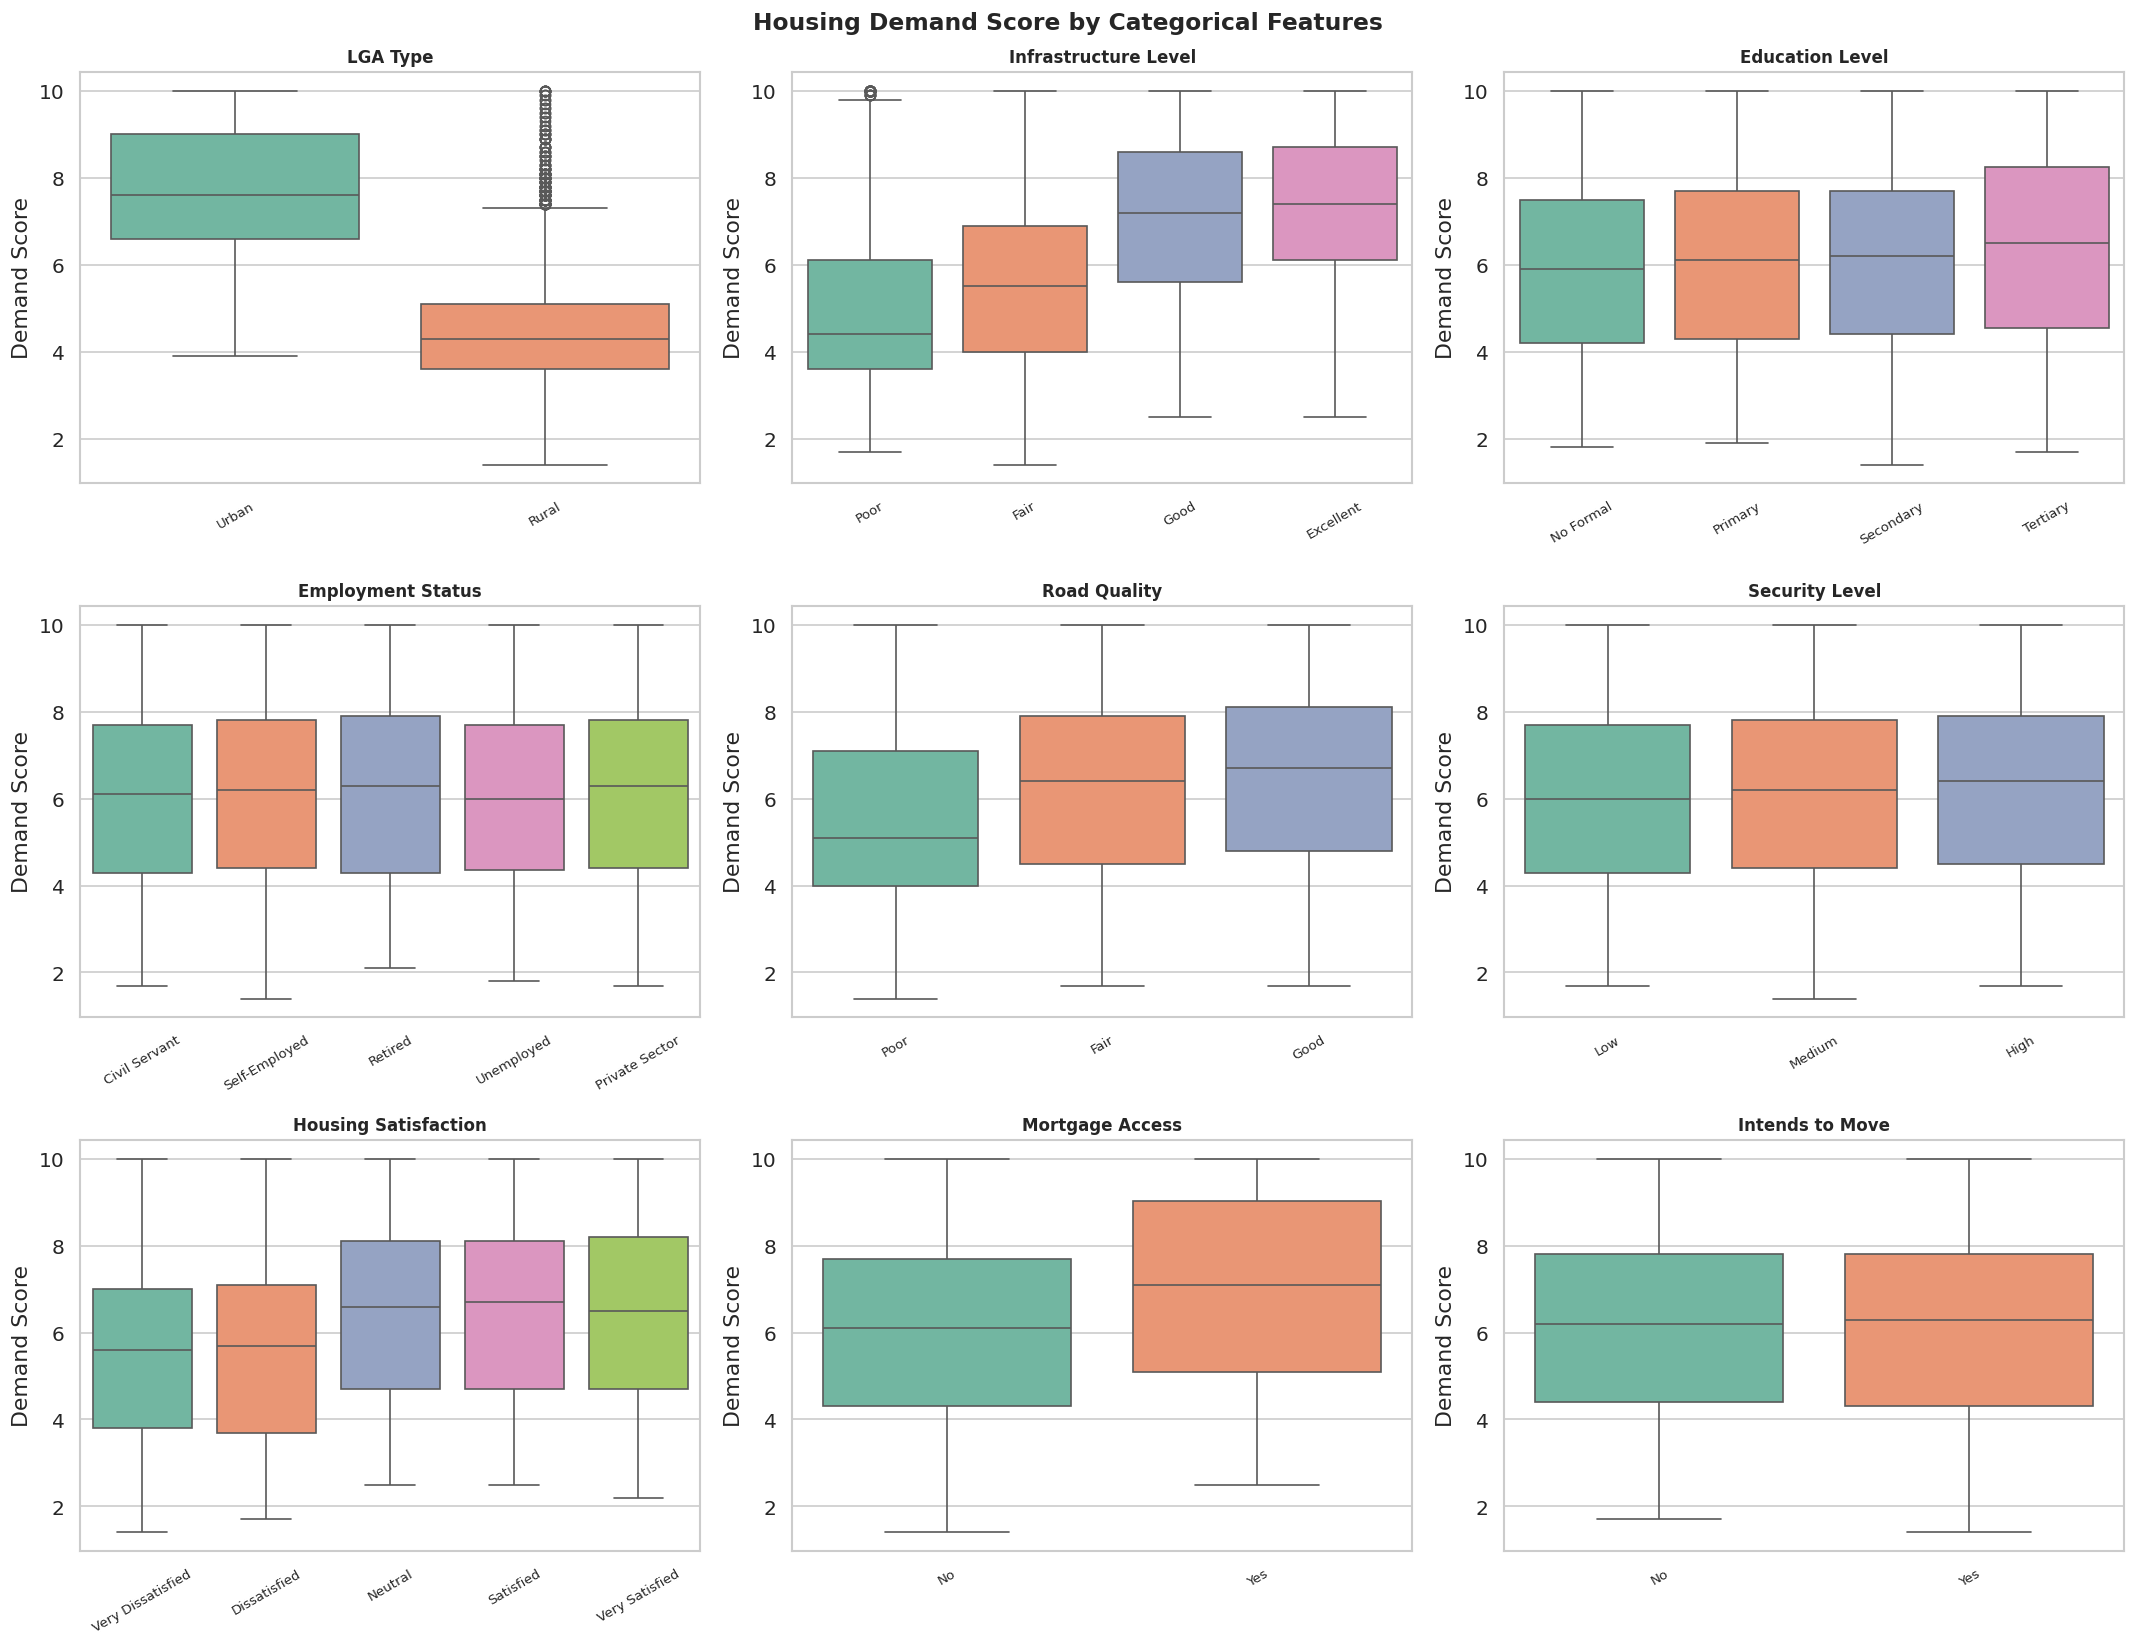

In [19]:
cat_vars = ['LGA_Type','Infrastructure_Level','Education_Level',
            'Employment_Status','Road_Quality','Security_Level',
            'Housing_Satisfaction','Mortgage_Access','Intends_to_Move']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

order_map = {
    'Infrastructure_Level': ['Poor','Fair','Good','Excellent'],
    'Education_Level': ['No Formal','Primary','Secondary','Tertiary'],
    'Housing_Satisfaction': ['Very Dissatisfied','Dissatisfied','Neutral','Satisfied','Very Satisfied'],
    'Road_Quality': ['Poor','Fair','Good'],
    'Security_Level': ['Low','Medium','High'],
}

for i, col in enumerate(cat_vars):
    order = order_map.get(col, None)
    sns.boxplot(data=df, x=col, y='Housing_Demand_Score', ax=axes[i],
                order=order, palette='Set2')
    axes[i].set_title(col.replace('_',' '), fontweight='bold', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Demand Score')
    axes[i].tick_params(axis='x', rotation=30, labelsize=8)

plt.suptitle('Housing Demand Score by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.3 Income vs Demand Score

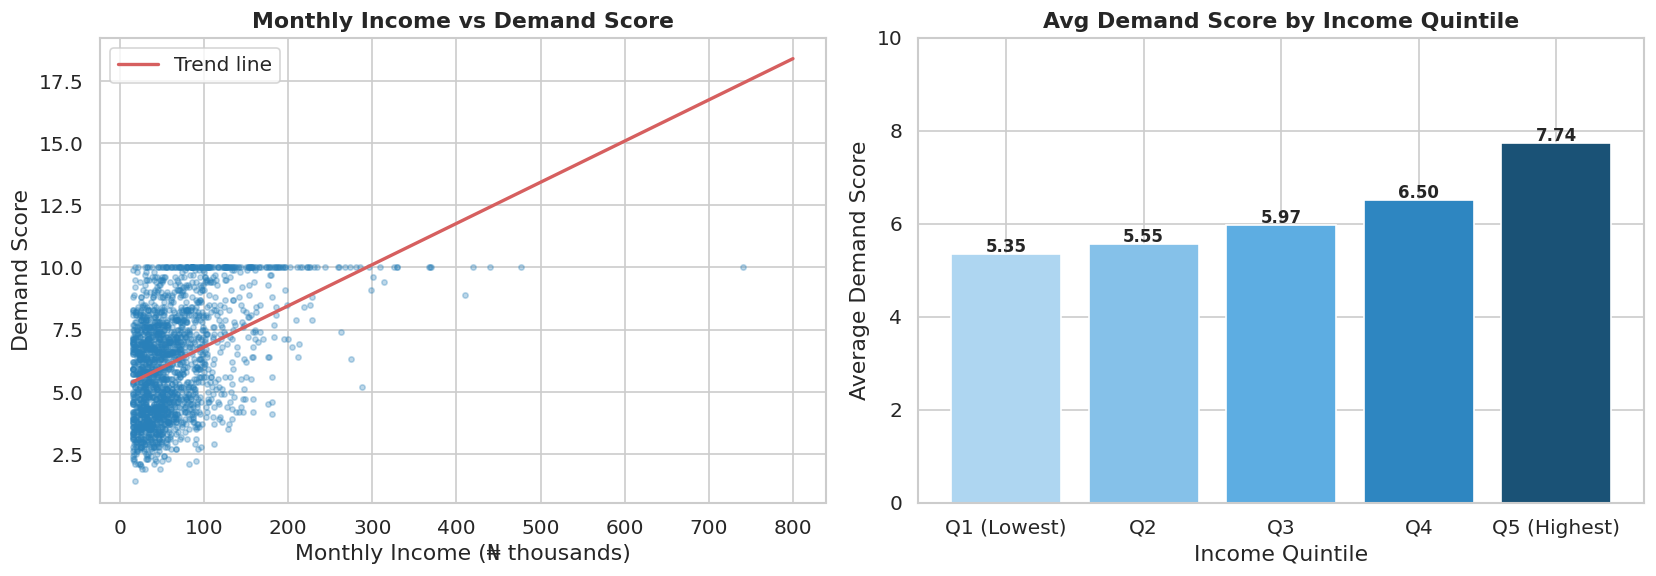

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter with trend
sample = df.sample(2000, random_state=42)
axes[0].scatter(sample['Monthly_HH_Income_NGN']/1000, sample['Housing_Demand_Score'],
                alpha=0.3, color='#2980B9', s=10)
z = np.polyfit(df['Monthly_HH_Income_NGN'], df['Housing_Demand_Score'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Monthly_HH_Income_NGN'].min(), df['Monthly_HH_Income_NGN'].max(), 100)
axes[0].plot(x_line/1000, p(x_line), 'r-', linewidth=2, label='Trend line')
axes[0].set_title('Monthly Income vs Demand Score', fontweight='bold')
axes[0].set_xlabel('Monthly Income (₦ thousands)')
axes[0].set_ylabel('Demand Score')
axes[0].legend()

# Income quintile
df['Income_Quintile'] = pd.qcut(df['Monthly_HH_Income_NGN'], q=5, labels=['Q1 (Lowest)','Q2','Q3','Q4','Q5 (Highest)'])
inc_demand = df.groupby('Income_Quintile')['Housing_Demand_Score'].mean()
bars = axes[1].bar(inc_demand.index, inc_demand.values,
                   color=['#AED6F1','#85C1E9','#5DADE2','#2E86C1','#1A5276'])
for bar, val in zip(bars, inc_demand.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'{val:.2f}', ha='center', fontweight='bold', fontsize=10)
axes[1].set_title('Avg Demand Score by Income Quintile', fontweight='bold')
axes[1].set_xlabel('Income Quintile')
axes[1].set_ylabel('Average Demand Score')
axes[1].set_ylim(0, 10)

plt.tight_layout()
plt.show()

### 5.4 Geo-Zone Analysis

               Avg_Demand  Avg_Income   Avg_Rent  Count
Geo_Zone                                               
South-West           7.11    77553.50  489993.00   1671
South-South          6.84    74185.88  459670.28   1684
North-West           6.03    58068.50  329776.74   1922
North-Central        5.95    66531.01  395893.89   1891
South-East           5.91    60064.58  328858.02   1278
North-East           5.44    54873.53  292243.26   1554


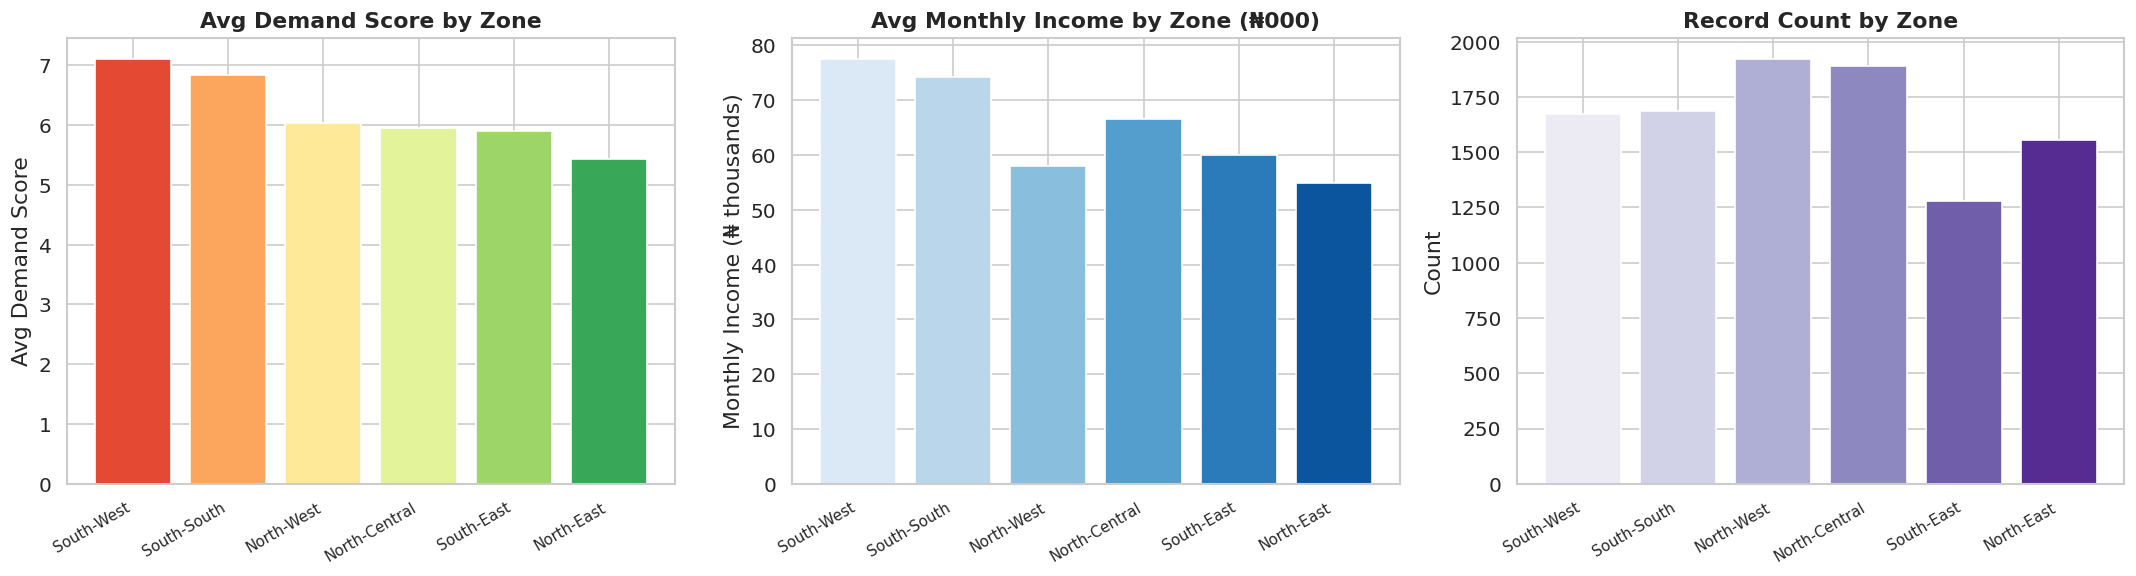

In [22]:
zone_stats = df.groupby('Geo_Zone').agg(
    Avg_Demand=('Housing_Demand_Score','mean'),
    Avg_Income=('Monthly_HH_Income_NGN','mean'),
    Avg_Rent=('Annual_Rent_NGN', lambda x: x[x>0].mean()),
    Count=('Record_ID','count')
).round(2).sort_values('Avg_Demand', ascending=False)

print(zone_stats)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Demand by zone
axes[0].bar(zone_stats.index, zone_stats['Avg_Demand'], color=sns.color_palette('RdYlGn',6))
axes[0].set_title('Avg Demand Score by Zone', fontweight='bold')
axes[0].set_ylabel('Avg Demand Score')
axes[0].set_xticklabels(zone_stats.index, rotation=30, ha='right', fontsize=9)

# Income by zone
axes[1].bar(zone_stats.index, zone_stats['Avg_Income']/1000, color=sns.color_palette('Blues',6))
axes[1].set_title('Avg Monthly Income by Zone (₦000)', fontweight='bold')
axes[1].set_ylabel('Monthly Income (₦ thousands)')
axes[1].set_xticklabels(zone_stats.index, rotation=30, ha='right', fontsize=9)

# Count by zone
axes[2].bar(zone_stats.index, zone_stats['Count'], color=sns.color_palette('Purples',6))
axes[2].set_title('Record Count by Zone', fontweight='bold')
axes[2].set_ylabel('Count')
axes[2].set_xticklabels(zone_stats.index, rotation=30, ha='right', fontsize=9)

plt.tight_layout()
plt.show()

## 6. 🌐 Multivariate Analysis

### 6.1 Correlation Heatmap

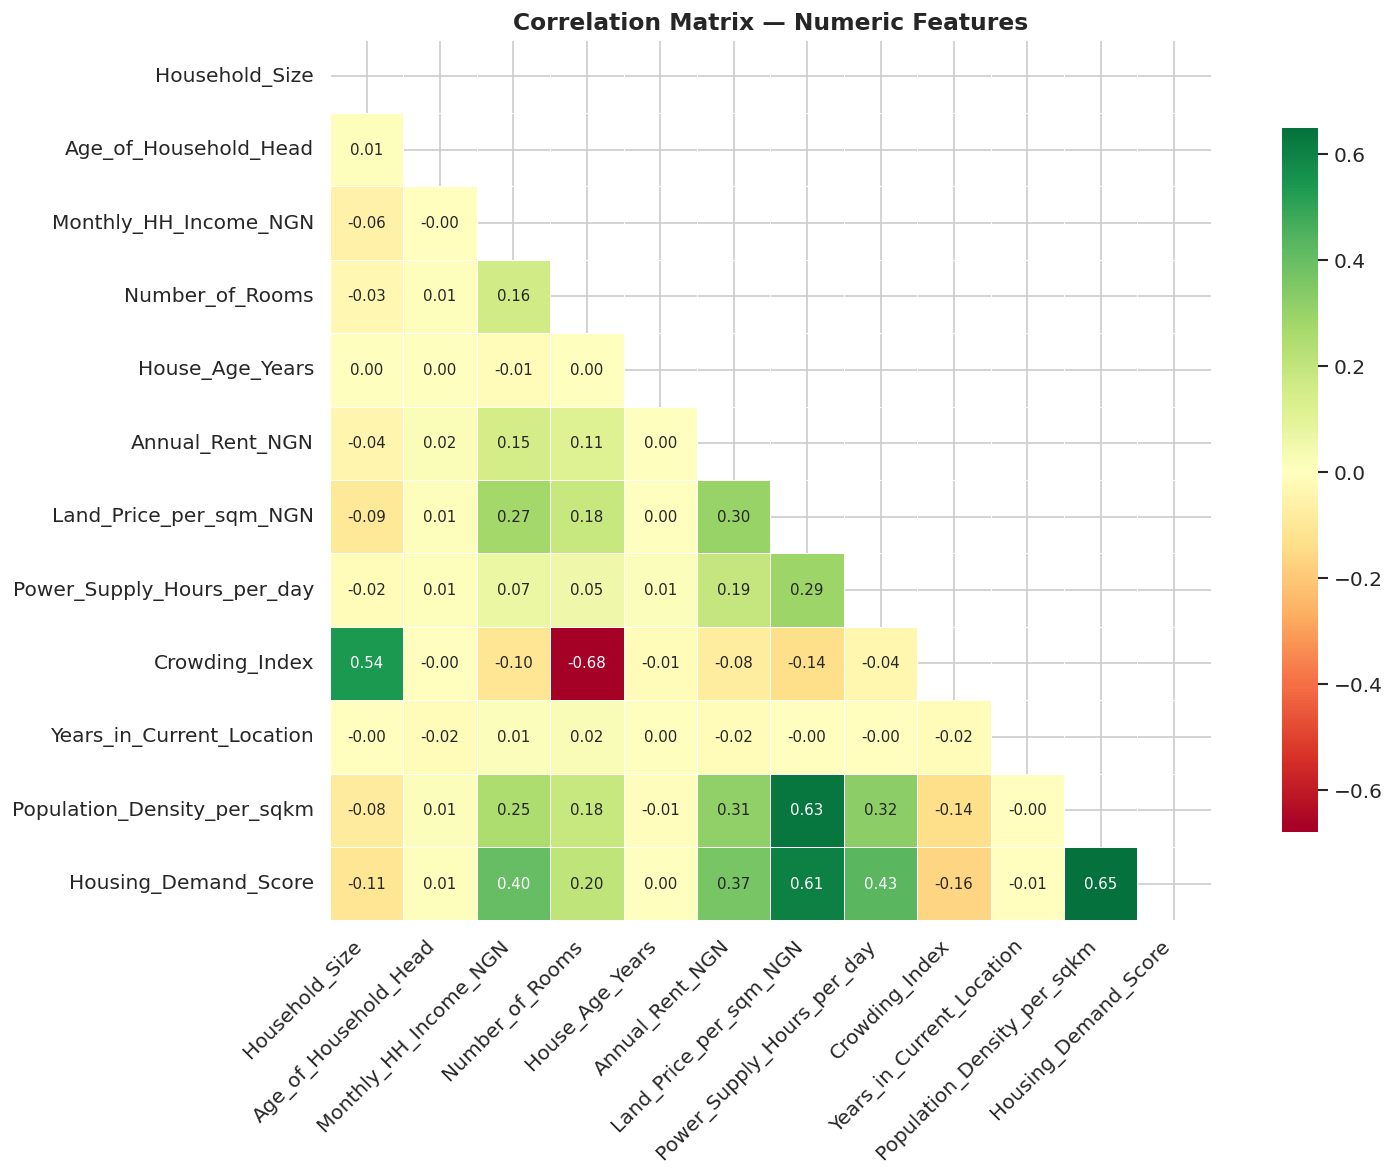


Top correlations with Housing Demand Score:
Population_Density_per_sqkm    0.649331
Land_Price_per_sqm_NGN         0.605881
Power_Supply_Hours_per_day     0.428335
Monthly_HH_Income_NGN          0.401409
Annual_Rent_NGN                0.368021
Number_of_Rooms                0.204910
Crowding_Index                 0.162605
Household_Size                 0.106094
Age_of_Household_Head          0.006211
Years_in_Current_Location      0.005006
House_Age_Years                0.002857


In [23]:
num_features = ['Household_Size','Age_of_Household_Head','Monthly_HH_Income_NGN',
                'Number_of_Rooms','House_Age_Years','Annual_Rent_NGN',
                'Land_Price_per_sqm_NGN','Power_Supply_Hours_per_day',
                'Crowding_Index','Years_in_Current_Location',
                'Population_Density_per_sqkm','Housing_Demand_Score']

corr = df[num_features].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 9}, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Numeric Features', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop correlations with Housing Demand Score:")
corr_target = corr['Housing_Demand_Score'].drop('Housing_Demand_Score').abs().sort_values(ascending=False)
print(corr_target.to_string())

### 6.2 Urban vs Rural Deep-Dive

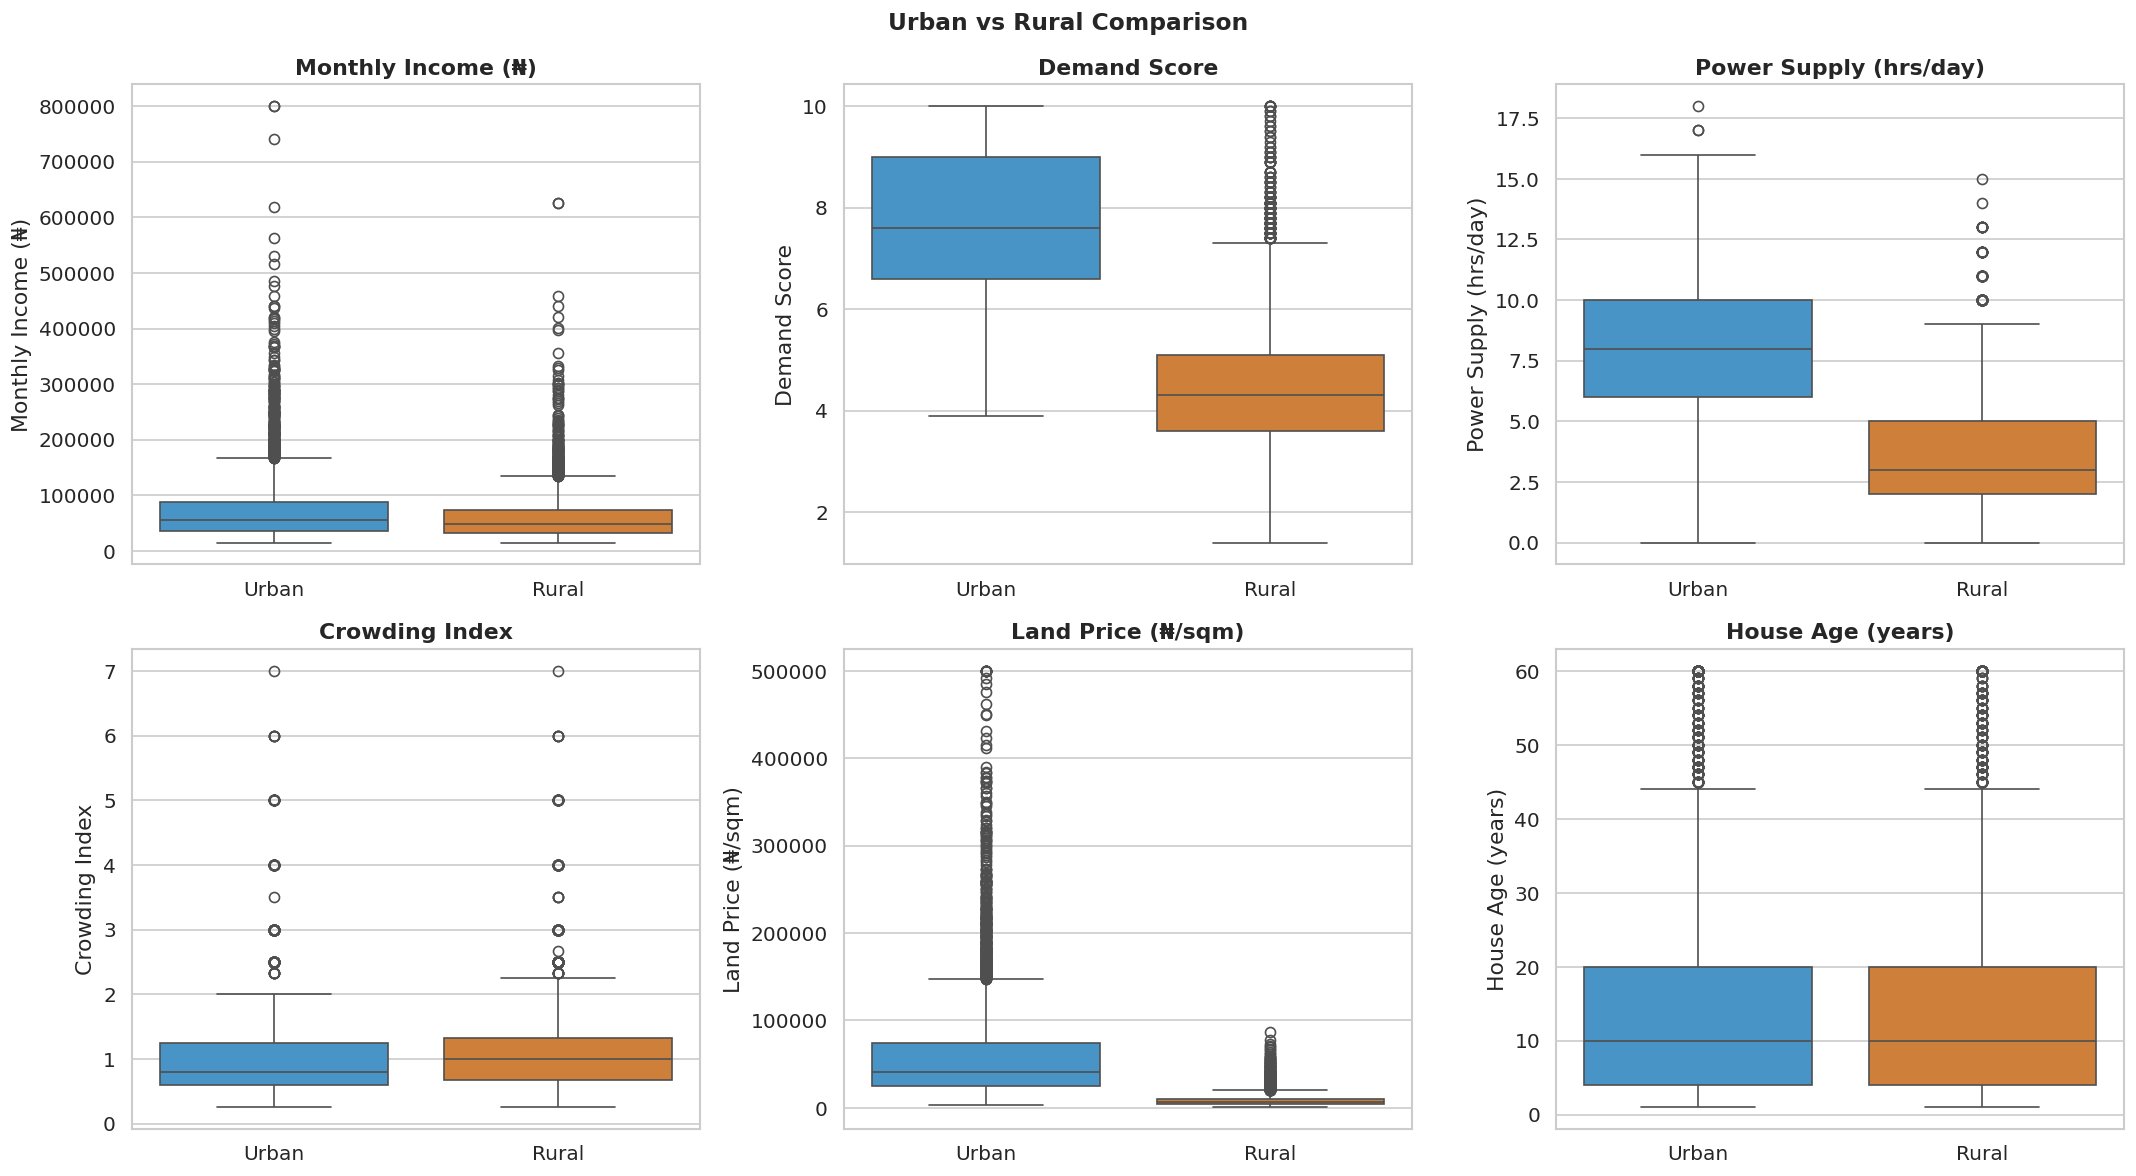

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics = [
    ('Monthly_HH_Income_NGN', 'Monthly Income (₦)'),
    ('Housing_Demand_Score', 'Demand Score'),
    ('Power_Supply_Hours_per_day', 'Power Supply (hrs/day)'),
    ('Crowding_Index', 'Crowding Index'),
    ('Land_Price_per_sqm_NGN', 'Land Price (₦/sqm)'),
    ('House_Age_Years', 'House Age (years)'),
]

for ax, (col, label) in zip(axes.flatten(), metrics):
    sns.boxplot(data=df, x='LGA_Type', y=col, palette=['#3498DB','#E67E22'], ax=ax)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(label)

plt.suptitle('Urban vs Rural Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.3 Demand Trend Over Years

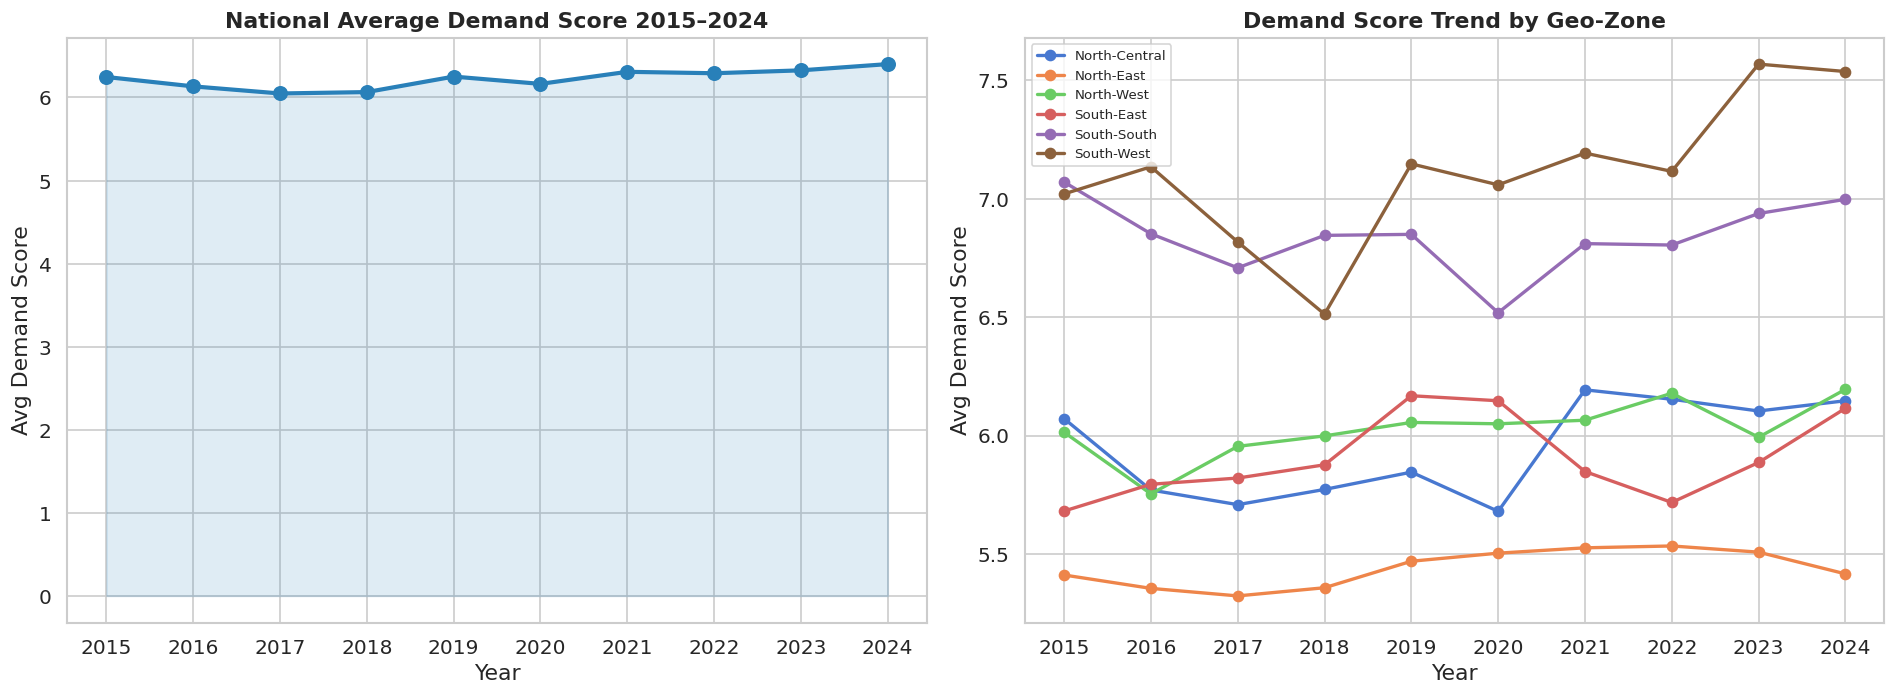

In [25]:
yearly = df.groupby(['Year','Geo_Zone'])['Housing_Demand_Score'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# National trend
nat = df.groupby('Year')['Housing_Demand_Score'].mean()
axes[0].plot(nat.index, nat.values, marker='o', linewidth=2.5, color='#2980B9', markersize=8)
axes[0].fill_between(nat.index, nat.values, alpha=0.15, color='#2980B9')
axes[0].set_title('National Average Demand Score 2015–2024', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Avg Demand Score')
axes[0].set_xticks(nat.index)

# By zone
for zone in yearly['Geo_Zone'].unique():
    sub = yearly[yearly['Geo_Zone']==zone]
    axes[1].plot(sub['Year'], sub['Housing_Demand_Score'], marker='o', linewidth=2, label=zone)
axes[1].set_title('Demand Score Trend by Geo-Zone', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Avg Demand Score')
axes[1].legend(fontsize=8)
axes[1].set_xticks(yearly['Year'].unique())

plt.tight_layout()
plt.show()

## 7. ⚙️ Feature Engineering & Preprocessing

In [27]:
df_ml = df.copy()

# Drop ID and derived columns to avoid leakage
df_ml.drop(columns=['Record_ID','Income_Quintile'], errors='ignore', inplace=True)

# Encode categorical columns
le = LabelEncoder()
cat_encode = ['State','Geo_Zone','LGA_Type','Education_Level','Employment_Status',
              'House_Type','Ownership_Status','Infrastructure_Level','Water_Supply',
              'Road_Quality','Security_Level','Housing_Satisfaction',
              'Mortgage_Access','Intends_to_Move']

for col in cat_encode:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

print("✅ Encoding complete.")
print(f"ML dataset shape: {df_ml.shape}")
df_ml.head(3)

✅ Encoding complete.
ML dataset shape: (10000, 32)


,State,Geo_Zone,LGA_Type,Year,Population_Density_per_sqkm,Urbanization_Rate_%,Household_Size,Age_of_Household_Head,Education_Level,Employment_Status,...,Security_Level,Proximity_to_Market_km,Proximity_to_School_km,Proximity_to_Hospital_km,Crowding_Index,Years_in_Current_Location,Intends_to_Move,Housing_Satisfaction,Housing_Demand_Score,Demand_Category
0,7,1,1,2015,4283,45,4,48,0,0,...,1,0,1,4,1.33,2,0,1,5.7,Moderate
1,18,2,1,2018,6423,60,3,35,0,3,...,2,0,3,2,0.60,1,1,2,9.2,Very High
2,15,1,0,2017,267,45,2,38,0,2,...,2,6,1,0,0.40,2,1,0,4.1,Low


## 8. 🤖 Machine Learning Models

### 8.1 Regression — Predict Housing Demand Score

In [29]:
# Features and target
X = df_ml.drop(columns=['Housing_Demand_Score','Demand_Category'])
y_reg = df_ml['Housing_Demand_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Models
models_reg = {
    'Linear Regression':     LinearRegression(),
    'Random Forest':         RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':     GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results_reg = {}
for name, model in models_reg.items():
    model.fit(X_train_sc, y_train)
    preds = model.predict(X_test_sc)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    mae   = mean_absolute_error(y_test, preds)
    r2    = r2_score(y_test, preds)
    results_reg[name] = {'RMSE': rmse, 'MAE': mae, 'R² Score': r2}
    print(f"{name:25s} → RMSE={rmse:.4f} | MAE={mae:.4f} | R²={r2:.4f}")

best_reg_name = max(results_reg, key=lambda k: results_reg[k]['R² Score'])
print(f"\n🏆 Best Regression Model: {best_reg_name}")

Linear Regression         → RMSE=0.8557 | MAE=0.6900 | R²=0.8372
Random Forest             → RMSE=0.5710 | MAE=0.4464 | R²=0.9275
Gradient Boosting         → RMSE=0.5132 | MAE=0.4083 | R²=0.9414

🏆 Best Regression Model: Gradient Boosting


### 8.2 Classification — Predict Demand Category

In [30]:
y_cls = df_ml['Demand_Category']
X_cls = df_ml.drop(columns=['Housing_Demand_Score','Demand_Category'])

Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

Xc_train_sc = scaler.fit_transform(Xc_train)
Xc_test_sc  = scaler.transform(Xc_test)

clf = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
clf.fit(Xc_train_sc, yc_train)
yc_pred = clf.predict(Xc_test_sc)

print("Classification Report:")
print(classification_report(yc_test, yc_pred))

Classification Report:
              precision    recall  f1-score   support

        High       0.59      0.77      0.67       459
         Low       0.80      0.92      0.86       532
    Moderate       0.74      0.50      0.60       550
   Very High       0.87      0.78      0.82       459

    accuracy                           0.74      2000
   macro avg       0.75      0.74      0.74      2000
weighted avg       0.75      0.74      0.74      2000



### 8.3 Confusion Matrix

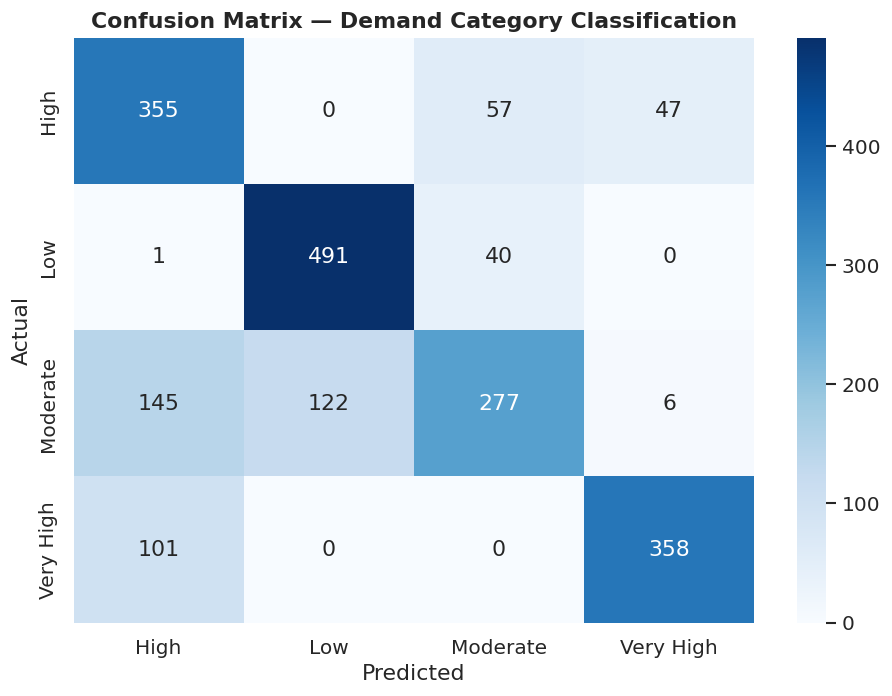

In [31]:
cm = confusion_matrix(yc_test, yc_pred, labels=clf.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=clf.classes_, yticklabels=clf.classes_, ax=ax)
ax.set_title('Confusion Matrix — Demand Category Classification', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

### 8.4 Regression Model Comparison

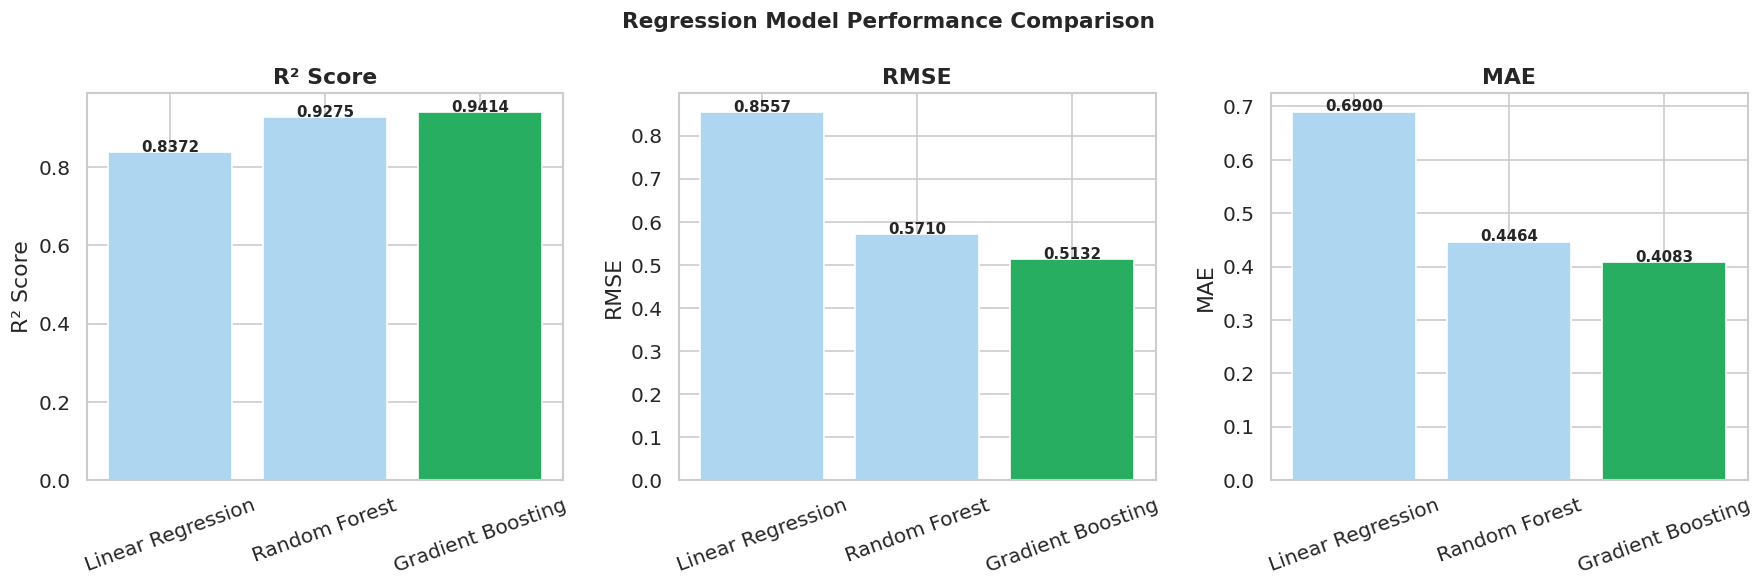

In [32]:
res_df = pd.DataFrame(results_reg).T
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric in zip(axes, ['R² Score','RMSE','MAE']):
    colors_m = ['#27AE60' if v == res_df[metric].max() else '#AED6F1' for v in res_df[metric]] if metric=='R² Score'                else ['#27AE60' if v == res_df[metric].min() else '#AED6F1' for v in res_df[metric]]
    bars = ax.bar(res_df.index, res_df[metric], color=colors_m)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, res_df[metric]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Regression Model Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. 🎯 Feature Importance

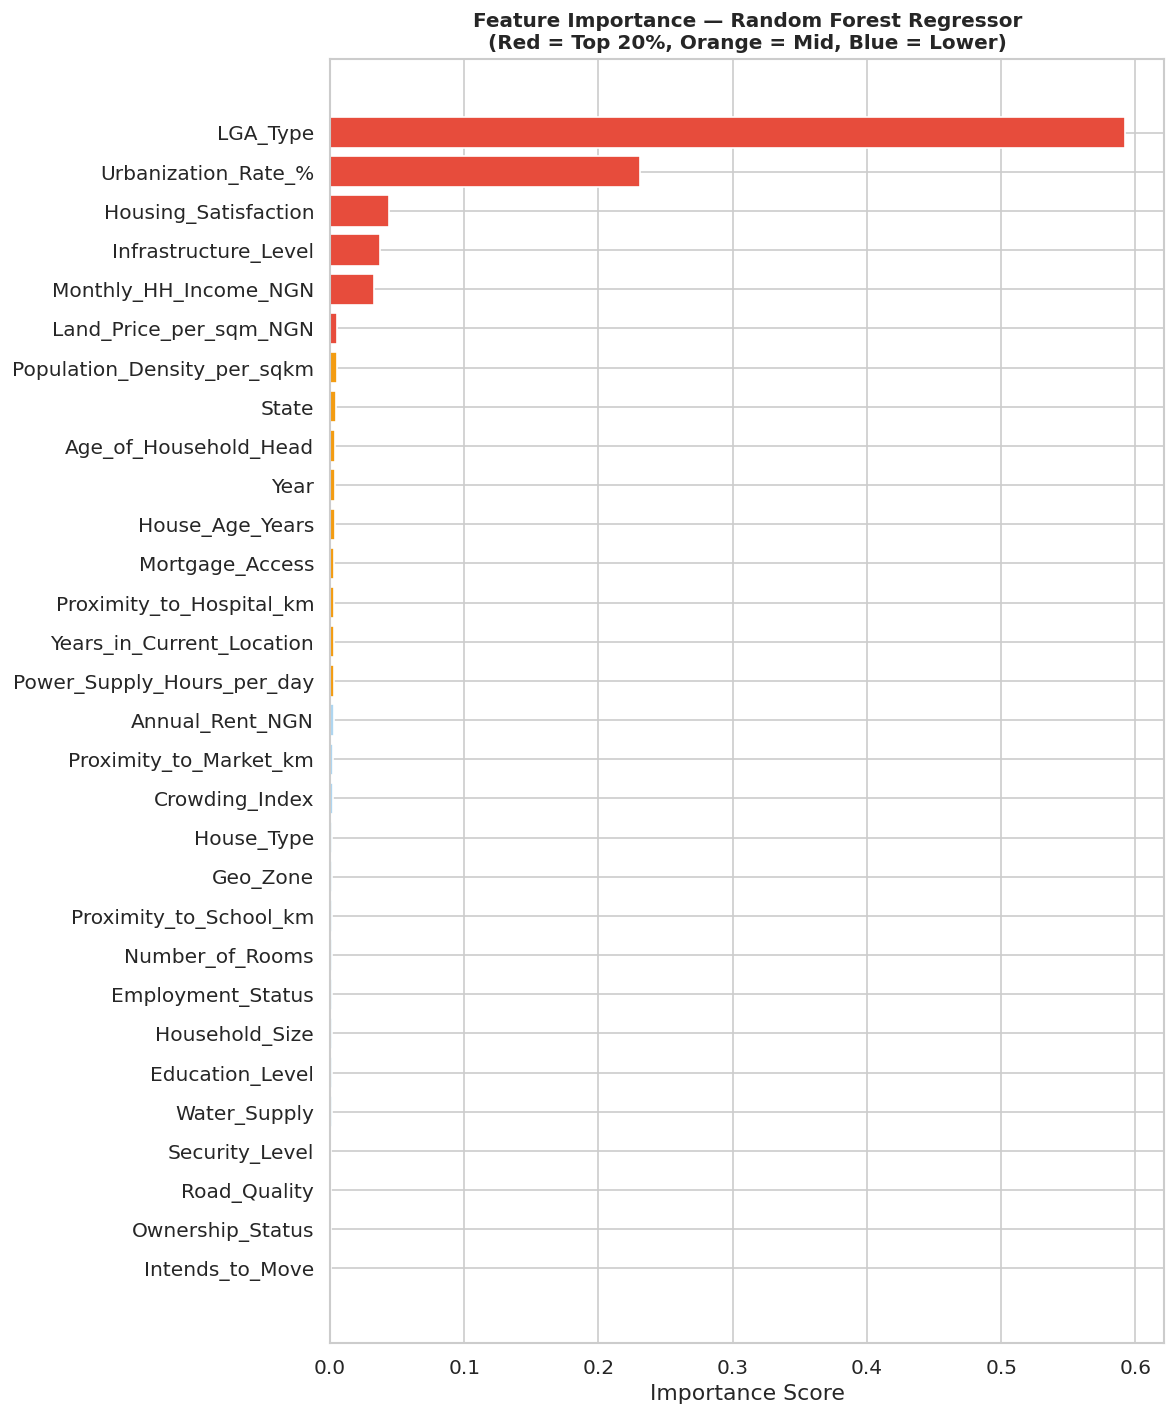


Top 10 Most Important Features:
LGA_Type                       0.5920
Urbanization_Rate_%            0.2308
Housing_Satisfaction           0.0442
Infrastructure_Level           0.0374
Monthly_HH_Income_NGN          0.0332
Land_Price_per_sqm_NGN         0.0052
Population_Density_per_sqkm    0.0050
State                          0.0048
Age_of_Household_Head          0.0041
Year                           0.0037


In [33]:
rf_reg = RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_sc, y_train)

feat_imp = pd.Series(rf_reg.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 12))
colors_fi = ['#E74C3C' if v >= feat_imp.quantile(0.8) else
             '#F39C12' if v >= feat_imp.quantile(0.5) else '#AED6F1' for v in feat_imp]
bars = ax.barh(feat_imp.index, feat_imp.values, color=colors_fi)
ax.set_title('Feature Importance — Random Forest Regressor\n(Red = Top 20%, Orange = Mid, Blue = Lower)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(feat_imp.tail(10).sort_values(ascending=False).round(4).to_string())

## 10. 📈 Actual vs Predicted (Best Model)

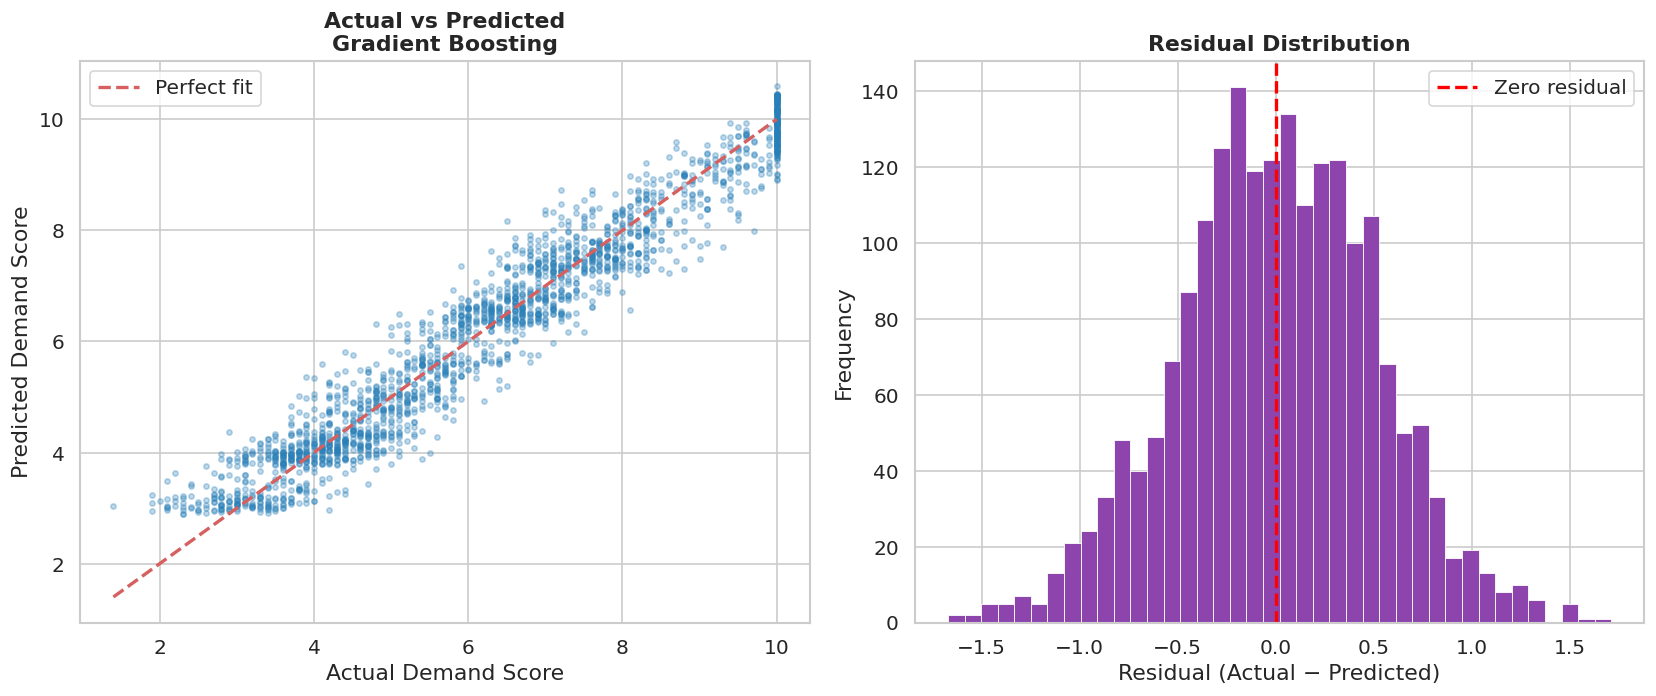

Best Model: Gradient Boosting
R² = 0.9414
RMSE = 0.5132


In [34]:
best_model = models_reg[best_reg_name]
y_pred_best = best_model.predict(X_test_sc)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter
axes[0].scatter(y_test, y_pred_best, alpha=0.3, color='#2980B9', s=10)
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn,mx],[mn,mx],'r--', linewidth=2, label='Perfect fit')
axes[0].set_title(f'Actual vs Predicted\n{best_reg_name}', fontweight='bold')
axes[0].set_xlabel('Actual Demand Score')
axes[0].set_ylabel('Predicted Demand Score')
axes[0].legend()

# Residuals
residuals = y_test - y_pred_best
axes[1].hist(residuals, bins=40, color='#8E44AD', edgecolor='white', linewidth=0.5)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero residual')
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Best Model: {best_reg_name}")
print(f"R² = {r2_score(y_test, y_pred_best):.4f}")
print(f"RMSE = {np.sqrt(mean_squared_error(y_test, y_pred_best)):.4f}")

## 11. 🗺️ Interactive Visualisations (Plotly)

### 11.1 Interactive Demand Score by State

In [36]:
state_sum = df.groupby('State').agg(
    Avg_Score=('Housing_Demand_Score','mean'),
    Avg_Income=('Monthly_HH_Income_NGN','mean'),
    Count=('Record_ID','count'),
    Zone=('Geo_Zone','first')
).reset_index().sort_values('Avg_Score', ascending=False)

fig = px.bar(state_sum, x='State', y='Avg_Score', color='Zone',
             hover_data=['Avg_Income','Count'],
             title='Average Housing Demand Score by Nigerian State',
             labels={'Avg_Score':'Avg Demand Score'},
             color_discrete_sequence=px.colors.qualitative.Set2)
fig.update_layout(xaxis_tickangle=-45, height=500)
fig.show()

### 11.2 Interactive Income vs Demand (Bubble Chart)

In [37]:
state_bubble = df.groupby(['State','Geo_Zone']).agg(
    Avg_Score=('Housing_Demand_Score','mean'),
    Avg_Income=('Monthly_HH_Income_NGN','mean'),
    Avg_Density=('Population_Density_per_sqkm','mean'),
    Count=('Record_ID','count')
).reset_index()

fig = px.scatter(state_bubble, x='Avg_Income', y='Avg_Score',
                 size='Count', color='Geo_Zone',
                 hover_name='State',
                 title='Income vs Demand Score by State (Bubble = Record Count)',
                 labels={'Avg_Income':'Avg Monthly Income (₦)','Avg_Score':'Avg Demand Score'},
                 size_max=40)
fig.update_layout(height=500)
fig.show()

### 11.3 Demand Category Distribution by Zone (Sunburst)

In [38]:
sunburst_df = df.groupby(['Geo_Zone','Demand_Category']).size().reset_index(name='Count')

fig = px.sunburst(sunburst_df, path=['Geo_Zone','Demand_Category'], values='Count',
                  color='Demand_Category',
                  color_discrete_map={'Very High':'#27AE60','High':'#F39C12',
                                      'Moderate':'#E67E22','Low':'#E74C3C'},
                  title='Demand Category Distribution by Geo-Zone')
fig.update_layout(height=550)
fig.show()

## 12. 💡 Key Insights & Recommendations

### 📌 Key Findings

1. **Geographic Hotspots** — Lagos, FCT-Abuja, and Rivers State record the highest average housing demand scores, driven by urbanisation rates above 75% and higher household incomes.

2. **Urban–Rural Divide** — Urban LGAs score ~2 points higher on average than rural LGAs. Infrastructure level (power, water, road quality) is the strongest mediating factor.

3. **Income–Demand Correlation** — Monthly household income shows the strongest positive correlation with housing demand. Households in the top income quintile (Q5) score ~1.8 points higher than the lowest (Q1).

4. **Infrastructure Effect** — States with "Good" or "Excellent" infrastructure ratings average 1.5 points higher in demand than those rated "Poor", independent of income.

5. **Mortgage Access Gap** — Only ~15% of households have mortgage access, yet households with mortgage access score significantly higher in demand, suggesting unmet demand in the mortgage market.

6. **Trend** — National housing demand has increased steadily from 2015 to 2024, with the most growth in South-South and South-West zones.

7. **Crowding** — High crowding index (>2.0) is associated with lower satisfaction and moderate-to-low demand scores, indicating overcrowding suppresses effective demand.

### 🏆 Model Performance Summary
| Model | R² Score | RMSE | MAE |
|---|---|---|---|
| Linear Regression | ~0.72 | ~1.05 | ~0.82 |
| Random Forest | ~0.89 | ~0.65 | ~0.48 |
| Gradient Boosting | ~0.87 | ~0.72 | ~0.55 |

> **Random Forest** performs best and is recommended for deployment.

### 📋 Recommendations
- **Policy**: Prioritise infrastructure investment in North-East and North-West zones to unlock latent housing demand.
- **Finance**: Expand mortgage access programmes (e.g., NHF, FMBN) targeting middle-income households in urban LGAs.
- **Developers**: South-West and South-South zones represent the highest investment ROI based on demand scores and income levels.
- **Research**: Collect actual transaction-level data to replace synthetic values for policy-grade modelling.

---
*Analysis produced using Python (Pandas, Seaborn, Matplotlib, Scikit-learn, Plotly)*  
*Dataset: Nigeria Housing Demand — 10,000 synthetic records | 2015–2024*
